Task2. Determine is it 0 or 1?

In [20]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd

X,y = fetch_openml('mnist_784', version=1,return_X_y=True, as_frame=False)

In [21]:
#normalize pixels
X = X/225.0

#format into char to int
y = y.astype(np.int64)

#choose onlu 0 & 1 for task
mask = (y==0) | (y==1)
X=X[mask]
y=y[mask]


In [ ]:
#write nessesary funсtions 
def sigmoid(z):
    return 1 / (1+np.exp(-z))

#y - target, P - predictions
def loss(y,P):
    n = y.shape[0]
    loss = (1/n)* np.sum(-y*np.log(P) - (1-y)*np.log(1-P))
    return loss 

def gredient_descent(X,y,P):
    n=X.shape[0]
    dw = (1/n)*X.T.dot(P-y)
    db = (1/n)*np.sum(P-y)
    return dw,db 

In [23]:
#max error,criteria for stop learning
eps = 0.01

#initial error value
loss_ = 1.0

#initilaze initial variables for model
w = np.zeros(X.shape[1])
b = 0

In [25]:
#train model
loss_history = [] 
max_iteration = 5000
learning_rate = 0.1 

for iteration in range(max_iteration):
    z = X.dot(w) +b
    P = sigmoid(z)

    loss_ = loss(y,P)
    dw,db = d=gredient_descent(X,y,P)
    w -= learning_rate*dw
    b -= learning_rate*db

    if iteration%100==0:
        print(iteration, loss_)

    loss_history.append(loss_)
    
    if loss_ < eps:
        break


0 0.38776274621447604
100 0.01846027041675597
200 0.012370800669651036
300 0.009989117196680308


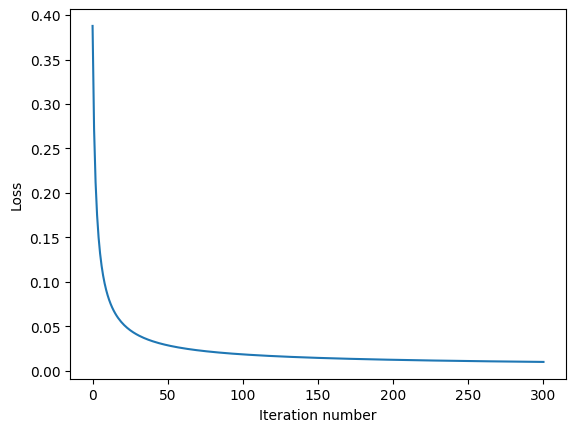

In [28]:
#plot error over iteration graph

import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iteration number")
plt.ylabel("Loss")
plt.show()


In [29]:
#predict
z = X.dot(w) + b
P = sigmoid(z)
y_pred = (P>= 0.5).astype(int)

y_pred

array([0, 1, 1, ..., 1, 0, 1])

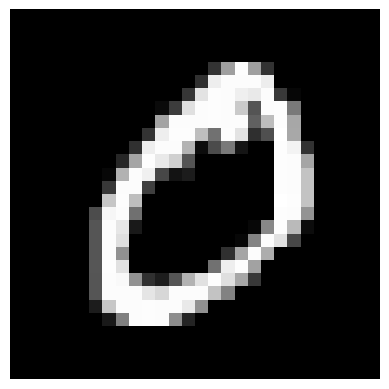

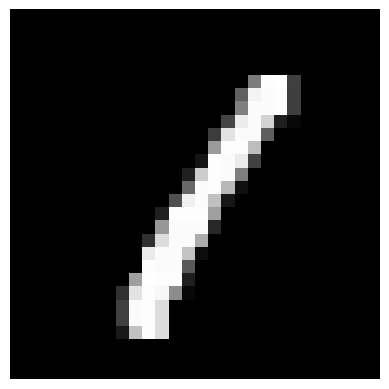

In [35]:
#showing the results
#write the function for printing image
def print_image(X):
    plt.imshow(X.reshape(28,28),cmap="gray")
    plt.axis("off")
    plt.show()

ex0 = np.where(y_pred==0)[0][0]
print_image(X[ex0])

ex1=np.where(y_pred==1)[0][0]
print_image(X[ex1])